# E-Commerce Price Intelligence EDA
Connect to BigQuery to analyze the latest data from the data warehouse.

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Initialize BigQuery Client
# The credentials and project are automatically loaded from the Docker environment variables
client = bigquery.Client()
project_id = os.environ.get('BIGQUERY_PROJECT_ID')
dataset_id = os.environ.get('BIGQUERY_DATASET')

print(f"Connected to project: {project_id}")

Connected to project: price-intelligence-2026


In [2]:
# Query the Category Trends Data Mart
query = f"""
SELECT product_category, product_count, mean_price 
FROM `{project_id}.{dataset_id}.mart_category_trends`
ORDER BY product_count DESC
"""
df = client.query(query).to_dataframe()
df.head()

,product_category,product_count,mean_price
0,Case,254,103.34
1,Mouse,249,55.56
2,RAM,239,400.68
3,Laptop,231,860.60
4,Keyboard,225,85.08


/tmp/ipykernel_201/2298408256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='mean_price', y='product_category', palette='viridis')


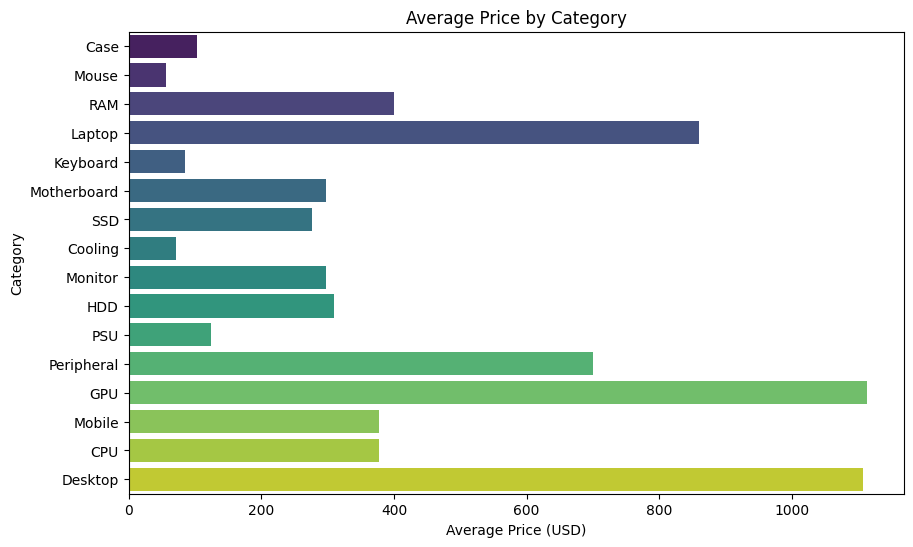

In [3]:
# Visualize the data
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='mean_price', y='product_category', palette='viridis')
plt.title('Average Price by Category')
plt.xlabel('Average Price (USD)')
plt.ylabel('Category')
plt.show()